Part 1 

In [2]:
import cv2
import numpy as np
import os
from pathlib import Path

def load_frames(frames_dir):
    """Load all frames from a directory, sorted by name."""
    frames_dir = Path(frames_dir)
    frame_files = sorted(frames_dir.glob("*.png")) + sorted(frames_dir.glob("*.jpg"))
    frames = []
    for f in frame_files:
        img = cv2.imread(str(f))  # loads as BGR
        if img is not None:
            frames.append(img)
    print(f"Loaded {len(frames)} frames")
    return frames

def bgr_to_ycbcr(bgr_frame):
    """Convert a BGR frame to YCbCr with chroma subsampling (4:2:0)."""
    
    # Step 1: BGR -> YCbCr
    ycbcr = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2YCrCb)
    
    # cv2 returns in order Y, Cr, Cb — reorder to Y, Cb, Cr
    Y  = ycbcr[:, :, 0]
    Cb = ycbcr[:, :, 2]
    Cr = ycbcr[:, :, 1]
    
    # Step 2: Chroma subsampling 4:2:0
    # Cb and Cr are downsampled by 2x in both width and height
    h, w = Y.shape
    Cb_sub = cv2.resize(Cb, (w // 2, h // 2), interpolation=cv2.INTER_LINEAR)
    Cr_sub = cv2.resize(Cr, (w // 2, h // 2), interpolation=cv2.INTER_LINEAR)
    
    return Y, Cb_sub, Cr_sub

def ycbcr_to_bgr(Y, Cb_sub, Cr_sub):
    """Reverse the process: YCbCr back to BGR (for verification)."""
    
    h, w = Y.shape
    
    # Upsample Cb and Cr back to full size
    Cb = cv2.resize(Cb_sub, (w, h), interpolation=cv2.INTER_LINEAR)
    Cr = cv2.resize(Cr_sub, (w, h), interpolation=cv2.INTER_LINEAR)
    
    # Stack in Y, Cr, Cb order (as cv2 expects)
    ycrcb = np.stack([Y, Cr, Cb], axis=2)
    
    # Convert back to BGR
    bgr = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)
    return bgr


# --- Run it ---
frames_bgr = load_frames("frames")

preprocessed = []
for frame in frames_bgr:
    Y, Cb, Cr = bgr_to_ycbcr(frame)
    preprocessed.append((Y, Cb, Cr))

print(f"Preprocessed {len(preprocessed)} frames")
print(f"Y shape:  {preprocessed[0][0].shape}")   # full resolution
print(f"Cb shape: {preprocessed[0][1].shape}")   # half resolution
print(f"Cr shape: {preprocessed[0][2].shape}")   # half resolution


Loaded 250 frames
Preprocessed 250 frames
Y shape:  (288, 352)
Cb shape: (144, 176)
Cr shape: (144, 176)


Part 2

In [3]:
import numpy as np
from scipy.fft import dctn, idctn

QUANT_MATRIX = np.array([
    [16, 11, 10, 16, 24,  40,  51,  61],
    [12, 12, 14, 19, 26,  58,  60,  55],
    [14, 13, 16, 24, 40,  57,  69,  56],
    [14, 17, 22, 29, 51,  87,  80,  62],
    [18, 22, 37, 56, 68,  109, 103, 77],
    [24, 35, 55, 64, 81,  104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
], dtype=np.float32)


def get_quant_matrix(quality=50):

    # Sécurité : on limite quality entre 1 et 100
    if quality <= 0:
        quality = 1
    if quality > 100:
        quality = 100

    # Calcul du facteur d'échelle selon la formule standard JPEG
    if quality < 50:
        scale = 5000 / quality      
    else:
        scale = 200 - 2 * quality   

    # On multiplie chaque valeur de la matrice par le facteur d'échelle
    # np.floor arrondit vers le bas, +50 sert à arrondir correctement
    qm = np.floor((QUANT_MATRIX * scale + 50) / 100)

    # On s'assure que aucune valeur n'est 0  ni > 255
    qm = np.clip(qm, 1, 255)

    return qm.astype(np.float32)


def split_into_blocks(channel, block_size=8):

    h, w = channel.shape  # dimensions originales du canal

    # Si la taille n'est pas un multiple de 8, on ajoute du padding
    pad_h = (block_size - h % block_size) % block_size
    pad_w = (block_size - w % block_size) % block_size

    # mode='edge' répète les pixels du bord (meilleur que mettre des zéros)
    padded = np.pad(channel, ((0, pad_h), (0, pad_w)), mode='edge')

    ph, pw = padded.shape  # dimensions après padding

    # Reshape intelligent pour créer les blocs sans boucle
    # padded (240, 320) → (30, 8, 40, 8)
    blocks = padded.reshape(ph // block_size, block_size,
                            pw // block_size, block_size)

    # Réorganise les axes pour avoir : (nb_blocs_h, nb_blocs_w, 8, 8)
    blocks = blocks.transpose(0, 2, 1, 3)

    # On retourne aussi la taille originale pour supprimer le padding plus tard
    return blocks, (h, w)


def merge_blocks(blocks, original_shape, block_size=8):

    num_bh, num_bw, _, _ = blocks.shape  

    # Inverse du transpose fait dans split_into_blocks
    blocks = blocks.transpose(0, 2, 1, 3)  

    # Reshape pour recoller tous les blocs en une seule image
    channel = blocks.reshape(num_bh * block_size, num_bw * block_size)

    # Supprime le padding en recadrant à la taille originale
    h, w = original_shape
    return channel[:h, :w]


def dct_block(block):

    return dctn(block.astype(np.float32) - 128, norm='ortho')


def idct_block(block):

    return idctn(block, norm='ortho') + 128


def quantise_block(dct_block, quant_matrix):

    return np.round(dct_block / quant_matrix).astype(np.int16)


def dequantise_block(quant_block, quant_matrix):

    return (quant_block * quant_matrix).astype(np.float32)


def encode_channel(channel, quant_matrix):

    # Étape 1 : découper en blocs 8x8
    blocks, original_shape = split_into_blocks(channel)
    num_bh, num_bw, _, _ = blocks.shape  

    # Tableau vide pour stocker les blocs encodés
    encoded = np.zeros_like(blocks, dtype=np.int16)

    # Étape 2 : pour chaque bloc, appliquer DCT puis quantification
    for i in range(num_bh):      
        for j in range(num_bw):   
            block = blocks[i, j]                        
            dct = dct_block(block)                      
            encoded[i, j] = quantise_block(dct, quant_matrix)  

    return encoded, original_shape


def decode_channel(encoded_blocks, original_shape, quant_matrix):

    num_bh, num_bw, _, _ = encoded_blocks.shape
    decoded_blocks = np.zeros_like(encoded_blocks, dtype=np.float32)

    for i in range(num_bh):
        for j in range(num_bw):
            # Étape 1 : dequantification
            dequant = dequantise_block(encoded_blocks[i, j], quant_matrix)
            # Étape 2 : IDCT pour retrouver les pixels
            decoded_blocks[i, j] = idct_block(dequant)

    # Clip : les erreurs d'arrondi peuvent donner des valeurs < 0 ou > 255
    decoded_blocks = np.clip(decoded_blocks, 0, 255)

    # Recolle les blocs et supprime le padding
    return merge_blocks(decoded_blocks, original_shape)


def encode_iframe(Y, Cb, Cr, quality=50):

    # Calcule la matrice de quantification selon la qualité choisie
    qm = get_quant_matrix(quality)

    # Encode chaque canal séparément
    Y_enc,  Y_shape  = encode_channel(Y,  qm)   
    Cb_enc, Cb_shape = encode_channel(Cb, qm)  
    Cr_enc, Cr_shape = encode_channel(Cr, qm)   

    return (Y_enc, Cb_enc, Cr_enc), (Y_shape, Cb_shape, Cr_shape), qm


def decode_iframe(encoded_channels, shapes, quant_matrix):

    Y_enc, Cb_enc, Cr_enc = encoded_channels
    Y_shape, Cb_shape, Cr_shape = shapes

    # Décode chaque canal indépendamment
    Y_dec  = decode_channel(Y_enc,  Y_shape,  quant_matrix)
    Cb_dec = decode_channel(Cb_enc, Cb_shape, quant_matrix)
    Cr_dec = decode_channel(Cr_enc, Cr_shape, quant_matrix)

    # Convertit en uint8 (entiers 0-255) pour les pixels finaux
    return Y_dec.astype(np.uint8), Cb_dec.astype(np.uint8), Cr_dec.astype(np.uint8)



QUALITY = 50  # Facteur de qualité : 1 (max compression) → 100 (meilleure qualité)
              # Fais varier cette valeur pour ton rapport !

encoded_iframes = []  # liste qui stocke toutes les I-frames encodées

# Encode chaque frame de la liste preprocessed (venant de la Partie 1)
for idx, (Y, Cb, Cr) in enumerate(preprocessed):
    encoded, shapes, qm = encode_iframe(Y, Cb, Cr, quality=QUALITY)
    encoded_iframes.append({
        "encoded": encoded,   
        "shapes":  shapes,   
        "qm":      qm      
    })

print(f"Encodé {len(encoded_iframes)} I-frames")

# --- Vérification : décode la première frame et affiche les dimensions ---
first = encoded_iframes[0]
Y_dec, Cb_dec, Cr_dec = decode_iframe(first["encoded"], first["shapes"], first["qm"])

print(f"Y décodé  : {Y_dec.shape}")   
print(f"Cb décodé : {Cb_dec.shape}")  
print(f"Cr décodé : {Cr_dec.shape}")   

Encodé 250 I-frames
Y décodé  : (288, 352)
Cb décodé : (144, 176)
Cr décodé : (144, 176)


Part 3

In [4]:
import numpy as np
from scipy.fft import dctn, idctn

# PARAMÈTRES PRINCIPAUX

GOP_SIZE = 5        # Toutes les 5 frames → I-frame, le reste → P-frames
SEARCH_WINDOW = 8   # Cherche le meilleur bloc dans ±8 pixels
BLOCK_SIZE = 16     # Taille des macroblocs : 16×16 pixels
QUALITY = 50        # Facteur de qualité pour la quantification


# MATRICES DE QUANTIFICATION

QUANT_MATRIX = np.array([
    [16, 11, 10, 16, 24,  40,  51,  61],
    [12, 12, 14, 19, 26,  58,  60,  55],
    [14, 13, 16, 24, 40,  57,  69,  56],
    [14, 17, 22, 29, 51,  87,  80,  62],
    [18, 22, 37, 56, 68,  109, 103, 77],
    [24, 35, 55, 64, 81,  104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
], dtype=np.float32)


def get_quant_matrix(quality=50):
 
    if quality <= 0: quality = 1
    if quality > 100: quality = 100

    if quality < 50:
        scale = 5000 / quality
    else:
        scale = 200 - 2 * quality

    qm = np.floor((QUANT_MATRIX * scale + 50) / 100)
    qm = np.clip(qm, 1, 255)
    return qm.astype(np.float32)


def get_quant_matrix_16(quality=50):

    qm_8 = get_quant_matrix(quality)
    qm_16 = np.kron(qm_8, np.ones((2, 2), dtype=np.float32))
    return qm_16



# FONCTIONS DCT / IDCT (réutilisées de la Part 2)

def dct_block(block):
  
    return dctn(block.astype(np.float32) - 128, norm='ortho')


def idct_block(block):
  
    return idctn(block, norm='ortho') + 128


def split_into_blocks(channel, block_size=8):
 
    h, w = channel.shape
    pad_h = (block_size - h % block_size) % block_size
    pad_w = (block_size - w % block_size) % block_size
    padded = np.pad(channel, ((0, pad_h), (0, pad_w)), mode='edge')
    ph, pw = padded.shape
    blocks = padded.reshape(ph // block_size, block_size,
                            pw // block_size, block_size)
    blocks = blocks.transpose(0, 2, 1, 3)
    return blocks, (h, w)


def merge_blocks(blocks, original_shape, block_size=8):

    num_bh, num_bw, _, _ = blocks.shape
    blocks = blocks.transpose(0, 2, 1, 3)
    channel = blocks.reshape(num_bh * block_size, num_bw * block_size)
    h, w = original_shape
    return channel[:h, :w]


def encode_channel(channel, quant_matrix):

    blocks, original_shape = split_into_blocks(channel, block_size=8)
    num_bh, num_bw, _, _ = blocks.shape
    encoded = np.zeros_like(blocks, dtype=np.int16)

    for i in range(num_bh):
        for j in range(num_bw):
            block = blocks[i, j]
            # Soustrait 128, applique DCT, quantifie
            dct = dctn(block.astype(np.float32) - 128, norm='ortho')
            encoded[i, j] = np.round(dct / quant_matrix).astype(np.int16)

    return encoded, original_shape


def decode_channel(encoded_blocks, original_shape, quant_matrix):

    num_bh, num_bw, _, _ = encoded_blocks.shape
    decoded_blocks = np.zeros_like(encoded_blocks, dtype=np.float32)

    for i in range(num_bh):
        for j in range(num_bw):
            # Dequantifie puis applique IDCT
            dequant = (encoded_blocks[i, j] * quant_matrix).astype(np.float32)
            decoded_blocks[i, j] = idctn(dequant, norm='ortho') + 128

    decoded_blocks = np.clip(decoded_blocks, 0, 255)
    return merge_blocks(decoded_blocks, original_shape, block_size=8)



# FONCTIONS I-FRAME (réutilisées de la Part 2)

def encode_iframe(Y, Cb, Cr, quality=50):

    qm = get_quant_matrix(quality)
    Y_enc,  Y_shape  = encode_channel(Y,  qm)
    Cb_enc, Cb_shape = encode_channel(Cb, qm)
    Cr_enc, Cr_shape = encode_channel(Cr, qm)
    return (Y_enc, Cb_enc, Cr_enc), (Y_shape, Cb_shape, Cr_shape), qm


def decode_iframe(encoded_channels, shapes, quant_matrix):

    Y_enc, Cb_enc, Cr_enc = encoded_channels
    Y_shape, Cb_shape, Cr_shape = shapes
    Y_dec  = decode_channel(Y_enc,  Y_shape,  quant_matrix)
    Cb_dec = decode_channel(Cb_enc, Cb_shape, quant_matrix)
    Cr_dec = decode_channel(Cr_enc, Cr_shape, quant_matrix)
    return Y_dec.astype(np.uint8), Cb_dec.astype(np.uint8), Cr_dec.astype(np.uint8)



# FONCTIONS UTILITAIRES POUR LES MACROBLOCS 16×16

def extract_block(frame, y, x, size=16):

    h, w = frame.shape
    y_end = min(y + size, h)
    x_end = min(x + size, w)
    block = frame[y:y_end, x:x_end]

    # Complète avec des zéros si le bloc est incomplet (bords de l'image)
    if block.shape != (size, size):
        padded = np.zeros((size, size), dtype=np.float32)
        padded[:block.shape[0], :block.shape[1]] = block
        return padded

    return block.astype(np.float32)


def compute_sad(block1, block2):
    return np.sum(np.abs(block1.astype(np.float32) -
                         block2.astype(np.float32)))



# ESTIMATION DE MOUVEMENT

def find_best_match(current_block, ref_frame, y, x, search_window):
    h, w = ref_frame.shape
    best_sad = float('inf')
    best_dy  = 0
    best_dx  = 0

    for dy in range(-search_window, search_window + 1):
        for dx in range(-search_window, search_window + 1):

            ref_y = y + dy
            ref_x = x + dx

            # Ignore les positions hors de l'image
            if ref_y < 0 or ref_x < 0:
                continue
            if ref_y + BLOCK_SIZE > h or ref_x + BLOCK_SIZE > w:
                continue

            # Extrait le bloc candidat et calcule la SAD
            candidate = extract_block(ref_frame, ref_y, ref_x, BLOCK_SIZE)
            sad = compute_sad(current_block, candidate)

            # Garde le meilleur candidat
            if sad < best_sad:
                best_sad = sad
                best_dy  = dy
                best_dx  = dx

    return best_dy, best_dx



# ENCODAGE / DÉCODAGE DU RÉSIDU 16×16

def encode_residual(residual, qm_16):

    # DCT sur le résidu 16×16
    dct_coeffs = dctn(residual.astype(np.float32), norm='ortho')

    # Quantification avec la matrice 16×16
    quantised = np.round(dct_coeffs / qm_16).astype(np.int16)

    return quantised


def decode_residual(quantised, qm_16):
    # Dequantification
    dct_coeffs = (quantised * qm_16).astype(np.float32)

    # IDCT pour retrouver le résidu spatial
    residual = idctn(dct_coeffs, norm='ortho')

    return residual



# ENCODAGE D'UNE P-FRAME

def encode_pframe(current_Y, ref_Y, quality):

    # Matrice 16×16 pour les résidus
    qm_16 = get_quant_matrix_16(quality)

    h, w = current_Y.shape
    motion_vectors = []
    residuals_enc  = []

    for y in range(0, h, BLOCK_SIZE):
        for x in range(0, w, BLOCK_SIZE):

            # Étape 1 : extrait le bloc courant 16×16
            current_block = extract_block(current_Y, y, x, BLOCK_SIZE)

            # Étape 2 : motion estimation → trouve (dy, dx)
            dy, dx = find_best_match(current_block, ref_Y, y, x, SEARCH_WINDOW)
            motion_vectors.append((dy, dx))

            # Étape 3 : extrait le bloc prédit depuis la référence
            predicted_block = extract_block(ref_Y, y + dy, x + dx, BLOCK_SIZE)

            # Étape 4 : calcule le résidu
            # Si prédiction parfaite → résidu = 0 → très compressible !
            residual = current_block - predicted_block

            # Étape 5 : encode le résidu avec DCT 16×16
            enc_residual = encode_residual(residual, qm_16)
            residuals_enc.append(enc_residual)

    return motion_vectors, residuals_enc


# DÉCODAGE D'UNE P-FRAME

def decode_pframe(motion_vectors, residuals_enc, ref_Y, frame_shape, quality):

    # Matrice 16×16 pour les résidus
    qm_16 = get_quant_matrix_16(quality)

    h, w = frame_shape
    reconstructed_Y = np.zeros((h, w), dtype=np.float32)
    idx = 0

    for y in range(0, h, BLOCK_SIZE):
        for x in range(0, w, BLOCK_SIZE):

            # Étape 1 : récupère le motion vector
            dy, dx = motion_vectors[idx]

            # Étape 2 : extrait le bloc prédit depuis la référence
            predicted_block = extract_block(ref_Y, y + dy, x + dx, BLOCK_SIZE)

            # Étape 3 : décode le résidu
            residual = decode_residual(residuals_enc[idx], qm_16)

            # Étape 4 : reconstruit = prédiction + résidu
            reconstructed_block = predicted_block + residual

            # Étape 5 : place le bloc dans l'image reconstruite
            y_end = min(y + BLOCK_SIZE, h)
            x_end = min(x + BLOCK_SIZE, w)
            bh = y_end - y
            bw = x_end - x
            reconstructed_Y[y:y_end, x:x_end] = reconstructed_block[:bh, :bw]

            idx += 1

    return np.clip(reconstructed_Y, 0, 255).astype(np.uint8)



# PIPELINE COMPLET : ENCODE TOUTES LES FRAMES

def encode_video(preprocessed, quality=QUALITY):

    qm = get_quant_matrix(quality)
    encoded_frames = []
    ref_Y = None  # canal Y de la dernière frame reconstruite

    for idx, (Y, Cb, Cr) in enumerate(preprocessed):

        is_iframe = (idx % GOP_SIZE == 0)

        if is_iframe:
            # ---- I-FRAME ----
            print(f"Frame {idx} → I-frame")

            # Encode les 3 canaux (DCT 8×8)
            encoded, shapes, _ = encode_iframe(Y, Cb, Cr, quality)

            # Décode immédiatement pour avoir la référence reconstruite
            Y_rec, Cb_rec, Cr_rec = decode_iframe(encoded, shapes, qm)
            ref_Y = Y_rec.astype(np.float32)

            encoded_frames.append({
                "type":    "I",
                "encoded": encoded,   # (Y_enc, Cb_enc, Cr_enc)
                "shapes":  shapes,    # (Y_shape, Cb_shape, Cr_shape)
                "qm":      qm
            })

        else:
            # ---- P-FRAME ----
            print(f"Frame {idx} → P-frame")

            # Encode Y avec motion estimation + résidus 16×16
            motion_vectors, residuals_enc = encode_pframe(
                Y.astype(np.float32),
                ref_Y,
                quality
            )

            # Encode Cb et Cr comme des I-frames (DCT 8×8)
            # La compensation de mouvement sur Cb/Cr est optionnelle
            Cb_enc, Cb_shape = encode_channel(Cb, qm)
            Cr_enc, Cr_shape = encode_channel(Cr, qm)

            # Décode Y immédiatement pour mettre à jour la référence
            Y_rec = decode_pframe(
                motion_vectors,
                residuals_enc,
                ref_Y,
                Y.shape,
                quality
            )
            ref_Y = Y_rec.astype(np.float32)

            encoded_frames.append({
                "type":           "P",
                "motion_vectors": motion_vectors,  # liste de (dy, dx)
                "residuals_enc":  residuals_enc,   # résidus DCT 16×16 quantifiés
                "Cb_enc":         Cb_enc,
                "Cr_enc":         Cr_enc,
                "Cb_shape":       Cb_shape,
                "Cr_shape":       Cr_shape,
                "frame_shape":    Y.shape,
                "qm":             qm
            })

    return encoded_frames


# DÉCODAGE COMPLET DE LA VIDÉO

def decode_video(encoded_frames):

    decoded_frames = []
    ref_Y = None

    for idx, frame_data in enumerate(encoded_frames):

        if frame_data["type"] == "I":
            # ---- Décode une I-frame ----
            Y_dec, Cb_dec, Cr_dec = decode_iframe(
                frame_data["encoded"],
                frame_data["shapes"],
                frame_data["qm"]
            )
            ref_Y = Y_dec.astype(np.float32)

        else:
            # ---- Décode une P-frame ----
            qm = frame_data["qm"]

            # Reconstruit Y avec motion compensation + résidu
            Y_dec = decode_pframe(
                frame_data["motion_vectors"],
                frame_data["residuals_enc"],
                ref_Y,
                frame_data["frame_shape"],
                QUALITY
            )
            ref_Y = Y_dec.astype(np.float32)

            # Décode Cb et Cr (encodés comme I-frames)
            Cb_dec = decode_channel(frame_data["Cb_enc"], frame_data["Cb_shape"], qm)
            Cr_dec = decode_channel(frame_data["Cr_enc"], frame_data["Cr_shape"], qm)

            Y_dec  = Y_dec.astype(np.uint8)
            Cb_dec = Cb_dec.astype(np.uint8)
            Cr_dec = Cr_dec.astype(np.uint8)

        decoded_frames.append((Y_dec, Cb_dec, Cr_dec))
        print(f"Frame {idx} ({frame_data['type']}) décodée ✓")

    return decoded_frames


# EXÉCUTION

# Encode toutes les frames
encoded_frames = encode_video(preprocessed, quality=QUALITY)

print(f"\nTotal frames encodées : {len(encoded_frames)}")
print(f"I-frames : {sum(1 for f in encoded_frames if f['type'] == 'I')}")
print(f"P-frames : {sum(1 for f in encoded_frames if f['type'] == 'P')}")

# Décode toutes les frames pour vérification
decoded_frames = decode_video(encoded_frames)
print(f"\nTotal frames décodées : {len(decoded_frames)}")

Frame 0 → I-frame
Frame 1 → P-frame
Frame 2 → P-frame
Frame 3 → P-frame
Frame 4 → P-frame
Frame 5 → I-frame
Frame 6 → P-frame
Frame 7 → P-frame
Frame 8 → P-frame
Frame 9 → P-frame
Frame 10 → I-frame
Frame 11 → P-frame
Frame 12 → P-frame
Frame 13 → P-frame
Frame 14 → P-frame
Frame 15 → I-frame
Frame 16 → P-frame
Frame 17 → P-frame
Frame 18 → P-frame
Frame 19 → P-frame
Frame 20 → I-frame
Frame 21 → P-frame
Frame 22 → P-frame
Frame 23 → P-frame
Frame 24 → P-frame
Frame 25 → I-frame
Frame 26 → P-frame
Frame 27 → P-frame
Frame 28 → P-frame
Frame 29 → P-frame
Frame 30 → I-frame
Frame 31 → P-frame
Frame 32 → P-frame
Frame 33 → P-frame
Frame 34 → P-frame
Frame 35 → I-frame
Frame 36 → P-frame
Frame 37 → P-frame
Frame 38 → P-frame
Frame 39 → P-frame
Frame 40 → I-frame
Frame 41 → P-frame
Frame 42 → P-frame
Frame 43 → P-frame
Frame 44 → P-frame
Frame 45 → I-frame
Frame 46 → P-frame
Frame 47 → P-frame
Frame 48 → P-frame
Frame 49 → P-frame
Frame 50 → I-frame
Frame 51 → P-frame
Frame 52 → P-frame
Fra

Part 4

In [5]:
import pickle
import zlib
import struct
import os
import numpy as np

########################################## PART 4 : ENTROPY CODING & BINARY FILE I/O ##########################################


OUTPUT_BIN = "output.bin"


# encoded_frames → fichier .bin compressé
def write_bin(encoded_frames, output_path=OUTPUT_BIN):
    with open(output_path, 'wb') as f:
        f.write(b'MPEG4SIM')  # magic header

        # parcours des frames → sérialisation + compression zlib
        for frame_data in encoded_frames:
            ftype   = frame_data["type"]
            payload = {k: v for k, v in frame_data.items() if k != "type"}

            # conversion motion vectors → int16 pour réduire l'empreinte pickle
            if ftype == 'P' and "motion_vectors" in payload:
                payload["motion_vectors"] = np.array(
                    payload["motion_vectors"], dtype=np.int16)

            compressed = zlib.compress(pickle.dumps(payload), level=6)
            f.write(ftype.encode('ascii'))             # 1 byte : type
            f.write(struct.pack('>I', len(compressed)))  # 4 bytes : longueur
            f.write(compressed)

    file_size = os.path.getsize(output_path)
    print(f"[Part 4] Written {len(encoded_frames)} frames → '{output_path}'")
    print(f"[Part 4] Compressed size : {file_size:,} bytes  ({file_size/1024:.1f} KB)")
    return file_size


# fichier .bin → encoded_frames reconstruit
def read_bin(input_path=OUTPUT_BIN):
    encoded_frames = []

    with open(input_path, 'rb') as f:
        magic = f.read(8)
        if magic != b'MPEG4SIM':
            raise ValueError(f"Invalid file (magic={magic})")

        frame_idx = 0
        # lecture séquentielle des frames jusqu'à EOF
        while True:
            type_byte = f.read(1)
            if not type_byte:
                break  # EOF propre
            len_bytes = f.read(4)
            if len(len_bytes) < 4:
                break
            payload_len = struct.unpack('>I', len_bytes)[0]
            payload_bytes = f.read(payload_len)
            if len(payload_bytes) < payload_len:
                raise IOError(f"Truncated file at frame {frame_idx}")

            ftype   = type_byte.decode('ascii')
            payload = pickle.loads(zlib.decompress(payload_bytes))

            # restauration motion vectors numpy → liste de tuples (dy, dx)
            if ftype == 'P' and "motion_vectors" in payload:
                mv = payload["motion_vectors"]
                payload["motion_vectors"] = [
                    (int(mv[i, 0]), int(mv[i, 1])) for i in range(len(mv))]

            payload["type"] = ftype
            encoded_frames.append(payload)
            frame_idx += 1

    print(f"[Part 4] Read {len(encoded_frames)} frames from '{input_path}'")
    return encoded_frames







# taille brute Y+Cb+Cr de toutes les frames
original_size = sum(Y.nbytes + Cb.nbytes + Cr.nbytes
                    for Y, Cb, Cr in preprocessed)
print(f"[Part 4] Original raw size : {original_size:,} bytes  ({original_size/1024:.1f} KB)")

compressed_size = write_bin(encoded_frames, OUTPUT_BIN)

print(f"[Part 4] Compression ratio : {original_size / compressed_size:.2f}x")

# vérification round-trip
encoded_frames_loaded = read_bin(OUTPUT_BIN)
print(f"[Part 4] Round-trip OK : {len(encoded_frames_loaded)} frames")
print(f"  I: {sum(1 for f in encoded_frames_loaded if f['type']=='I')}  "
      f"P: {sum(1 for f in encoded_frames_loaded if f['type']=='P')}")


[Part 4] Original raw size : 38,016,000 bytes  (37125.0 KB)
[Part 4] Written 250 frames → 'output.bin'
[Part 4] Compressed size : 7,053,884 bytes  (6888.6 KB)
[Part 4] Compression ratio : 5.39x
[Part 4] Read 250 frames from 'output.bin'
[Part 4] Round-trip OK : 250 frames
  I: 50  P: 200


Part 5

  PART 5A — METRICS
  Frames           : 250  (I=50  P=200)
  Original size    : 38,016,000 bytes
  Compressed size  : 7,053,884 bytes
  Compression ratio: 5.39x


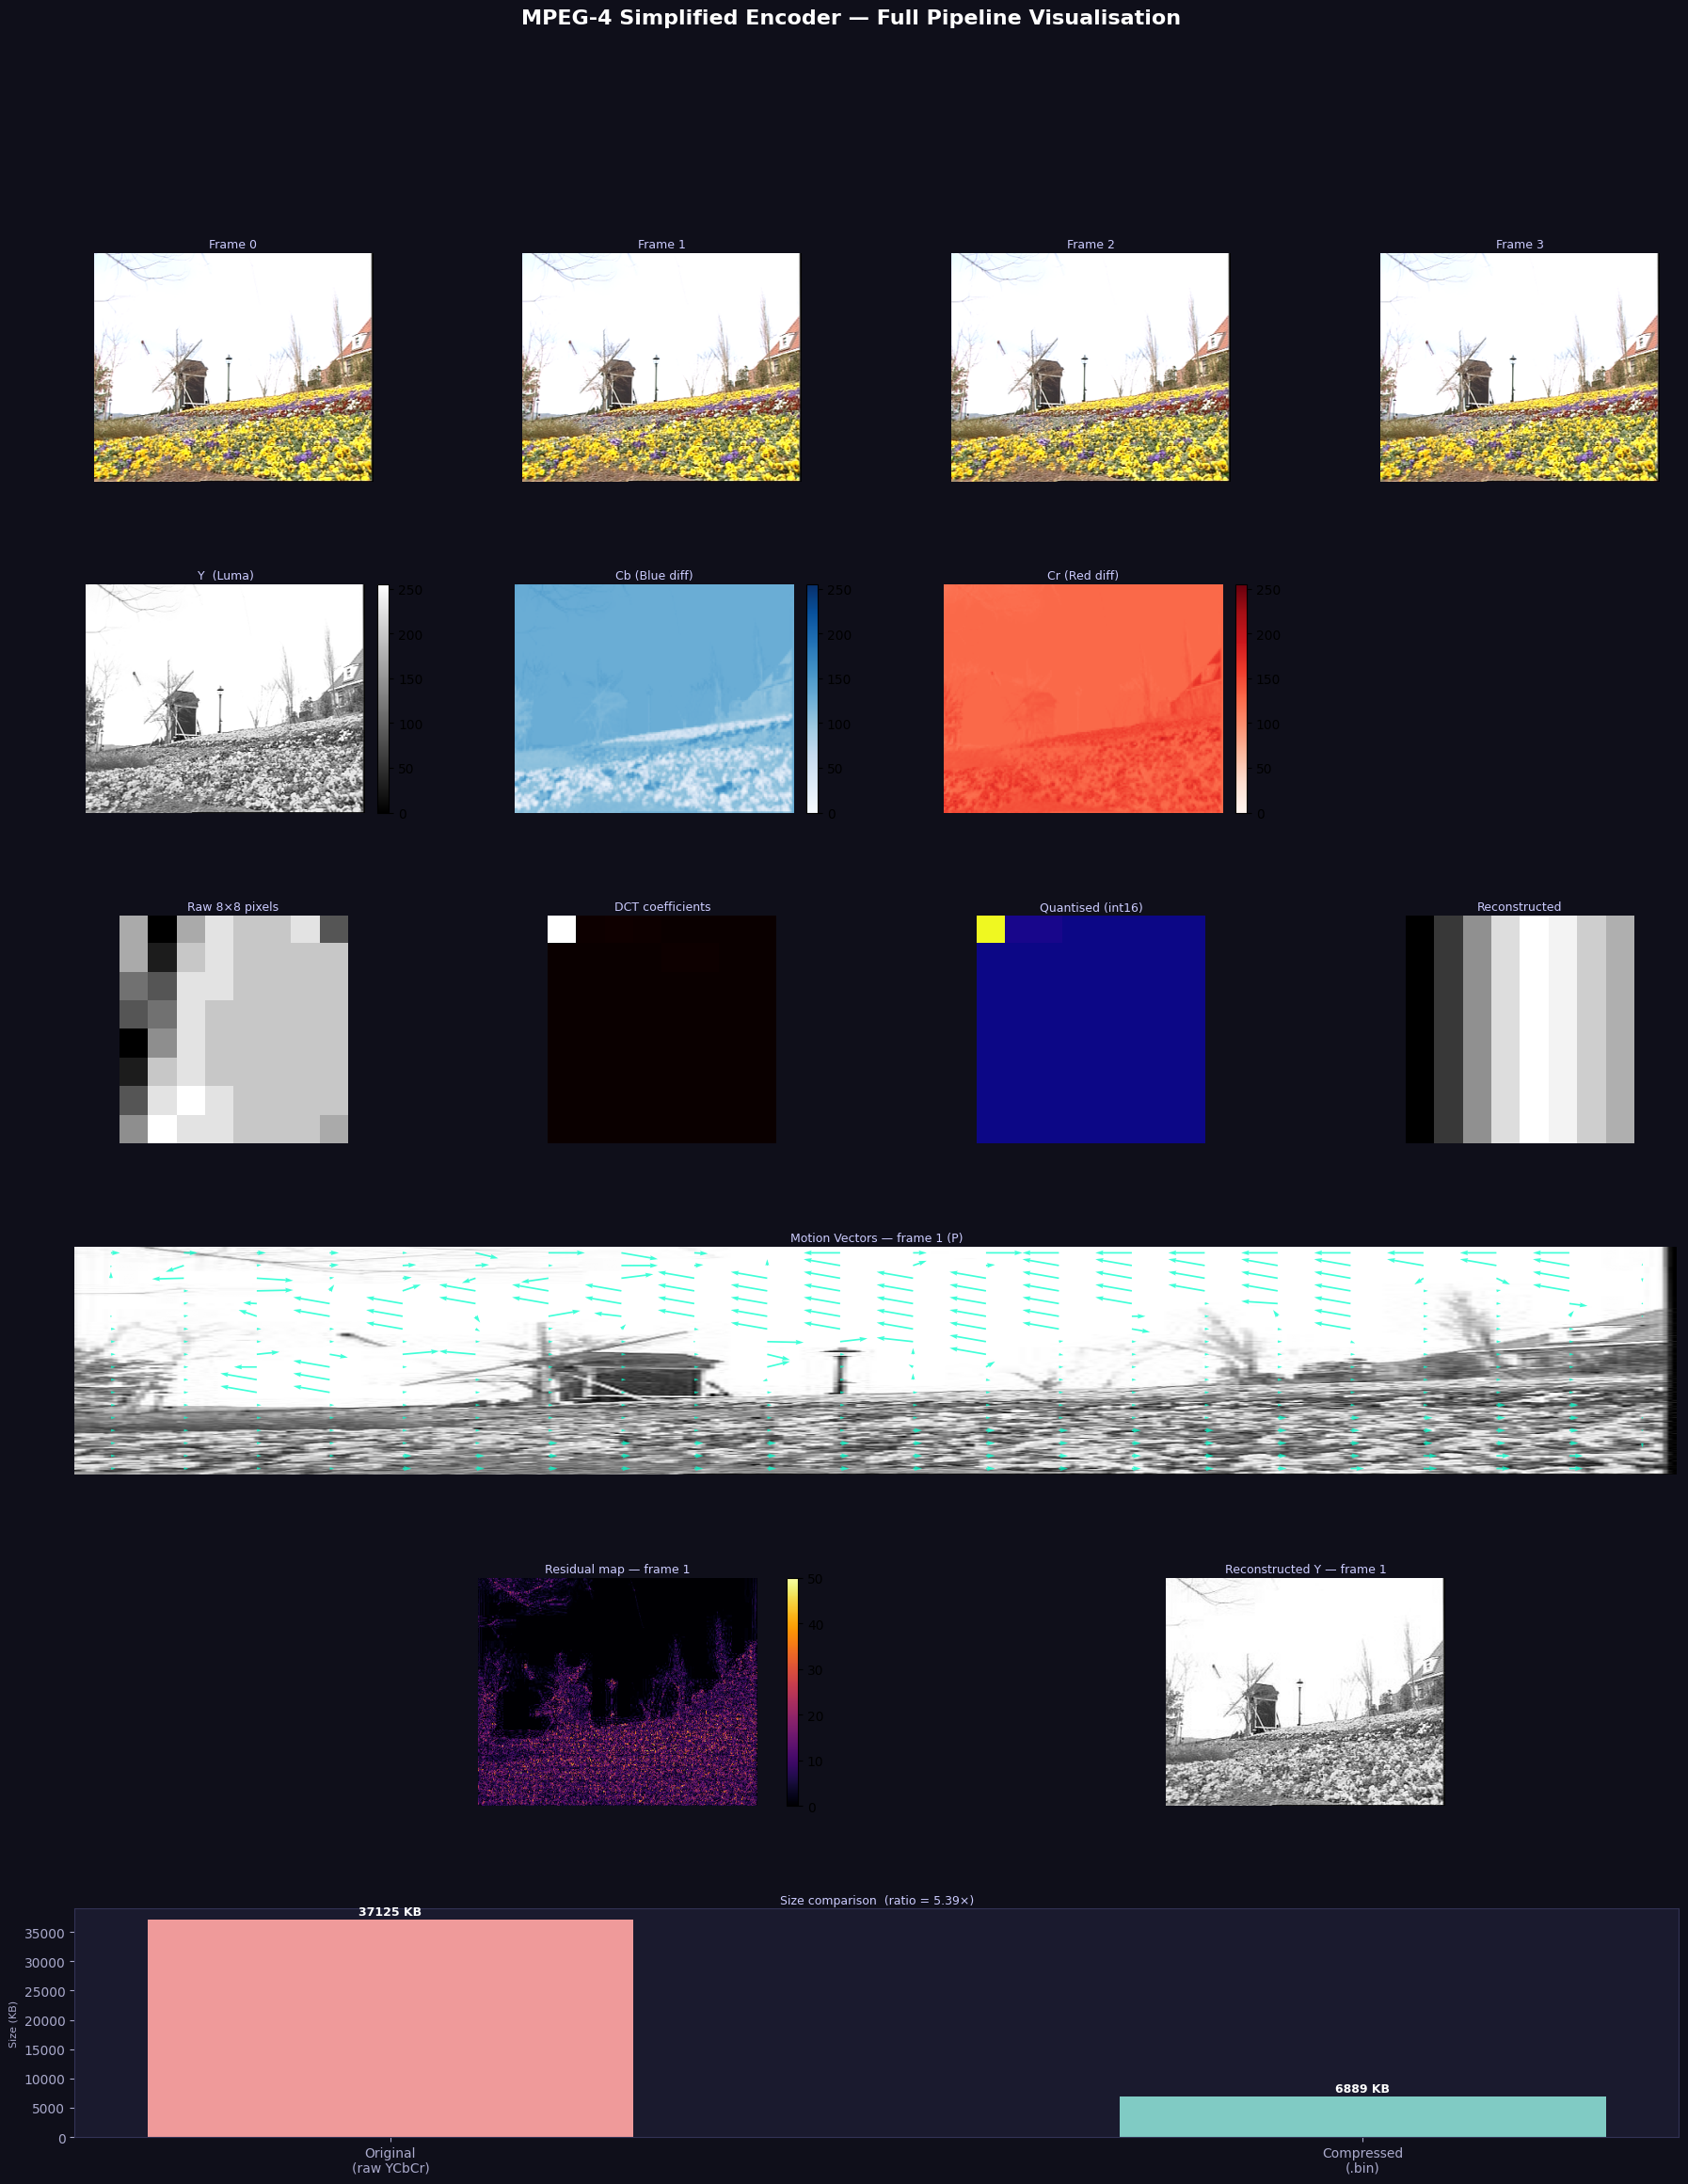

[Part 5] Figure saved → 'pipeline_visualisation.png'


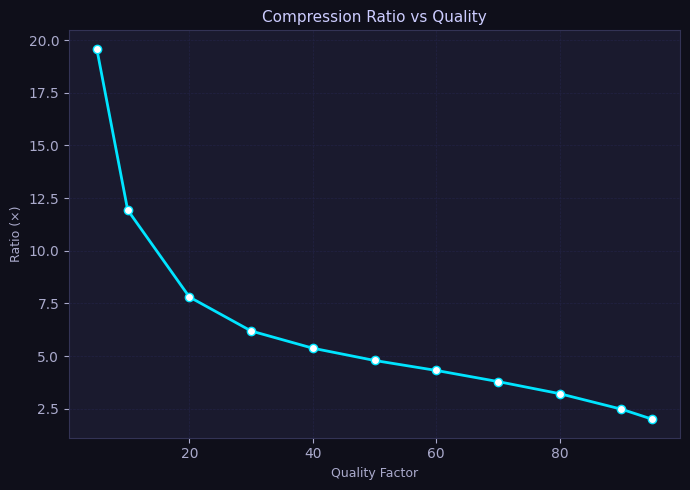

[Part 5] Ratio vs Quality chart saved → 'ratio_vs_quality.png'


In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.fft import dctn, idctn

########################################## PART 5 : EVALUATION & VISUALISATION #############################################


# ---- 5A : Quality Metrics ----

# preprocessed, decoded_frames, encoded_frames, tailles → affichage métriques + dict résultats
def evaluate_pipeline(preprocessed, decoded_frames, encoded_frames,
                      original_size, compressed_size):
    n_i = sum(1 for f in encoded_frames if f['type'] == 'I')
    n_p = sum(1 for f in encoded_frames if f['type'] == 'P')

    ratio = original_size / compressed_size

    print("=" * 50)
    print("  PART 5A — METRICS")
    print("=" * 50)
    print(f"  Frames           : {n_i + n_p}  (I={n_i}  P={n_p})")
    print(f"  Original size    : {original_size:,} bytes")
    print(f"  Compressed size  : {compressed_size:,} bytes")
    print(f"  Compression ratio: {ratio:.2f}x")
    print("=" * 50)

    return dict(ratio=ratio,
                original_size=original_size, compressed_size=compressed_size,
                n_i=n_i, n_p=n_p)


# ---- 5B : Pipeline Visualisation ----

# ax → mise en forme dark theme
def _ax_style(ax, title=""):
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='#aaaacc')
    for sp in ax.spines.values():
        sp.set_edgecolor('#333355')
    if title:
        ax.set_title(title, color='#ccccff', fontsize=9, pad=4)


# preprocessed, frames_bgr, encoded/decoded_frames, metrics → figure 6 lignes sauvegardée
def visualise_pipeline(preprocessed, frames_bgr, encoded_frames,
                       decoded_frames, metrics,
                       save_path="pipeline_visualisation.png"):
    fig = plt.figure(figsize=(22, 26))
    fig.patch.set_facecolor('#0f0f1a')
    plt.suptitle("MPEG-4 Simplified Encoder — Full Pipeline Visualisation",
                 fontsize=16, color='white', fontweight='bold', y=0.98)

    gs = GridSpec(6, 4, figure=fig, hspace=0.45, wspace=0.35)

    # Row 1 : affichage des frames originales
    n_show = min(4, len(frames_bgr))
    for k in range(n_show):
        ax = fig.add_subplot(gs[0, k])
        ax.imshow(cv2.cvtColor(frames_bgr[k], cv2.COLOR_BGR2RGB))
        ax.axis('off')
        _ax_style(ax, f"Frame {k}")

    # Row 2 : affichage des canaux Y / Cb / Cr de la frame 0
    Y0, Cb0, Cr0 = preprocessed[0]
    for col, (ch, title, cmap) in enumerate([
        (Y0,  "Y  (Luma)",      'gray'),
        (Cb0, "Cb (Blue diff)", 'Blues'),
        (Cr0, "Cr (Red diff)",  'Reds'),
    ]):
        ax = fig.add_subplot(gs[1, col])
        im = ax.imshow(ch, cmap=cmap, vmin=0, vmax=255)
        ax.axis('off')
        _ax_style(ax, title)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Row 3 : pipeline DCT sur un bloc 8×8 central
    h0, w0 = Y0.shape
    by, bx = (h0 // 19) // 8 * 8, (w0 // 19) // 8 * 8
    raw_block = Y0[by:by+8, bx:bx+8].astype(np.float32)
    qm        = get_quant_matrix(QUALITY)
    dct_c     = dctn(raw_block - 128, norm='ortho')
    q_block   = np.round(dct_c / qm)
    recon     = np.clip(idctn(q_block * qm, norm='ortho') + 128, 0, 255)

    # affichage des 4 étapes : brut → DCT → quantisé → reconstruit
    for col, (data, title, cmap) in enumerate([
        (raw_block,       "Raw 8×8 pixels",    'gray'),
        (np.abs(dct_c),   "DCT coefficients",  'hot'),
        (np.abs(q_block), "Quantised (int16)", 'plasma'),
        (recon,           "Reconstructed",      'gray'),
    ]):
        ax = fig.add_subplot(gs[2, col])
        ax.imshow(data, cmap=cmap, interpolation='nearest')
        ax.axis('off')
        _ax_style(ax, title)

    # Row 4 : recherche + affichage des motion vectors sur la première P-frame
    mv_idx = next(
        (i for i, f in enumerate(encoded_frames) if f['type'] == 'P'), None)

    ax_mv = fig.add_subplot(gs[3, :])  # pleine largeur
    ax_mv.set_facecolor('#1a1a2e')
    if mv_idx is not None:
        fd    = encoded_frames[mv_idx]
        Y_ref = decoded_frames[mv_idx][0]
        ax_mv.imshow(Y_ref, cmap='gray', vmin=0, vmax=255, aspect='auto')

        mvs = fd['motion_vectors']
        h_f, w_f = fd['frame_shape']
        BLK = 16
        xs, ys, us, vs = [], [], [], []
        # parcours des blocs → collecte des vecteurs non nuls
        for i, (dy, dx) in enumerate(mvs):
            if abs(dx) > 0 or abs(dy) > 0:
                cx = (i % (w_f // BLK)) * BLK + BLK // 2
                cy = (i // (w_f // BLK)) * BLK + BLK // 2
                xs.append(cx); ys.append(cy)
                us.append(dx); vs.append(dy)
        if xs:
            ax_mv.quiver(xs, ys, us, vs, color='#00ffcc',
                         scale=1, scale_units='xy', angles='xy',
                         width=0.001, alpha=0.75)
        ax_mv.set_xlim(0, w_f); ax_mv.set_ylim(h_f, 0)
        _ax_style(ax_mv, f"Motion Vectors — frame {mv_idx} (P)")
    else:
        ax_mv.text(0.5, 0.5, "No P-frames found",
                   ha='center', va='center', color='white', fontsize=12)
    ax_mv.axis('off')

    # Row 5 : affichage carte résiduelle + frame Y reconstruite
    if mv_idx is not None:
        Y_orig  = preprocessed[mv_idx][0].astype(np.float32)
        Y_recon = decoded_frames[mv_idx][0].astype(np.float32)
        residual_map = np.abs(Y_orig - Y_recon)

        ax_r = fig.add_subplot(gs[4, :2])
        im_r = ax_r.imshow(residual_map, cmap='inferno', vmin=0, vmax=50)
        ax_r.axis('off')
        _ax_style(ax_r, f"Residual map — frame {mv_idx}")
        plt.colorbar(im_r, ax=ax_r, fraction=0.046, pad=0.04)

        ax_k = fig.add_subplot(gs[4, 2:])
        ax_k.imshow(Y_recon, cmap='gray', vmin=0, vmax=255)
        ax_k.axis('off')
        _ax_style(ax_k, f"Reconstructed Y — frame {mv_idx}")

    # Row 6 : affichage comparaison des tailles
    ax_bar = fig.add_subplot(gs[5, :])  # pleine largeur

    sizes = [metrics['original_size']/1024, metrics['compressed_size']/1024]
    bars  = ax_bar.bar(['Original\n(raw YCbCr)', 'Compressed\n(.bin)'],
                       sizes, color=['#ef9a9a', '#80cbc4'],
                       edgecolor='none', width=0.5)
    # parcours des barres → annotation KB
    for b, v in zip(bars, sizes):
        ax_bar.text(b.get_x() + b.get_width()/2, b.get_height() + max(sizes)*0.01,
                    f"{v:.0f} KB", ha='center', va='bottom',
                    color='white', fontsize=9, fontweight='bold')
    ax_bar.set_ylabel("Size (KB)", color='#aaaacc', fontsize=8)
    _ax_style(ax_bar, f"Size comparison  (ratio = {metrics['ratio']:.2f}×)")

    plt.savefig(save_path, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"[Part 5] Figure saved → '{save_path}'")


# ----  Compression ratio vs Quality Factor: ----

# preprocessed → courbe ratio en fonction du quality factor
def plot_ratio_vs_quality(preprocessed,
                          quality_values=None,
                          save_path="ratio_vs_quality.png"):
    import pickle, zlib
    if quality_values is None:
        quality_values = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95]

    Y0, Cb0, Cr0 = preprocessed[0]
    raw_size = Y0.nbytes + Cb0.nbytes + Cr0.nbytes
    ratios = []

    # parcours des niveaux de qualité → encodage frame 0 + mesure ratio
    for q in quality_values:
        encoded, shapes, qm = encode_iframe(Y0, Cb0, Cr0, quality=q)
        comp_size = len(zlib.compress(pickle.dumps(
            {"encoded": encoded, "shapes": shapes, "qm": qm}), level=6))
        ratios.append(raw_size / comp_size)

    fig, ax1 = plt.subplots(1, 1, figsize=(7, 5))
    fig.patch.set_facecolor('#0f0f1a')

    # ax → mise en forme dark theme (locale)
    def _s(ax, title, xlabel, ylabel):
        ax.set_facecolor('#1a1a2e')
        ax.set_title(title,   color='#ccccff', fontsize=11)
        ax.set_xlabel(xlabel, color='#aaaacc', fontsize=9)
        ax.set_ylabel(ylabel, color='#aaaacc', fontsize=9)
        ax.tick_params(colors='#aaaacc')
        for sp in ax.spines.values(): sp.set_edgecolor('#333355')
        ax.grid(color='#222244', linestyle='--', linewidth=0.5)

    ax1.plot(quality_values, ratios, 'o-', color='#00e5ff',
             linewidth=2, markersize=6, markerfacecolor='white')
    _s(ax1, "Compression Ratio vs Quality", "Quality Factor", "Ratio (×)")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"[Part 5] Ratio vs Quality chart saved → '{save_path}'")







metrics = evaluate_pipeline(
    preprocessed, decoded_frames, encoded_frames,
    original_size, compressed_size
)

visualise_pipeline(
    preprocessed, frames_bgr, encoded_frames,
    decoded_frames, metrics
)

plot_ratio_vs_quality(preprocessed)